<a href="https://colab.research.google.com/github/ishikagoyal65/100-days-of-machine-learning/blob/main/Dog_v_s_Cat_classfier_DL_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
# ==========================================
# 1. SETUP KAGGLE API & DOWNLOAD DATASET
# ==========================================
# Note: Ensure you have uploaded your 'kaggle.json' file to the environment before running.

# Create the .kaggle folder
!mkdir -p ~/.kaggle

# Copy kaggle.json from the kaggle folder
!cp kaggle/kaggle.json ~/.kaggle/kaggle.json

# Give the correct permissions
!chmod 600 ~/.kaggle/kaggle.json

print("✅ Kaggle API configured successfully!")

cp: cannot stat 'kaggle/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
✅ Kaggle API configured successfully!


In [40]:
!pip install kaggle

In [41]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


In [42]:
import os

print(os.listdir(path))

['test', 'train', 'catsvsdogs']


In [43]:
# ==========================================
# 2. IMPORTS & DATA LOADING
# ==========================================

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [44]:
import os

# Check the Kaggle folder
print("Does /kaggle exist?", os.path.exists("/kaggle"))

if os.path.exists("/kaggle"):
    print("\nContents of /kaggle:")
    print(os.listdir("/kaggle"))

    print("\nContents of /kaggle/input:")
    print(os.listdir("/kaggle/input"))

Does /kaggle exist? True

Contents of /kaggle:
['input']

Contents of /kaggle/input:
['dogsvscats']


A generator is a TensorFlow/Keras utility that loads images in small batches and feeds them to a deep learning model during training, reducing memory usage and supporting real-time preprocessing and augmentation.

In [45]:
#generators

# Load the training dataset
train_ds = keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/dogsvscats/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

# Load the validation dataset
validation_ds = keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/dogsvscats/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)


Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [46]:
# ==========================================
# 3. DATA PREPROCESSING (NORMALIZATION)
# ==========================================
# Normalize pixel values from [0, 255] to [0, 1]
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [47]:
# ==========================================
# 4. CNN MODEL ARCHITECTURE
# ==========================================
model = Sequential()

# 1st Convolutional Block
model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 2nd Convolutional Block
model.add(Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 3rd Convolutional Block
model.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# Flattening and Fully Connected Layers
model.add(Flatten())

#Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))

# Output Layer for Binary Classification
model.add(Dense(1, activation='sigmoid'))

model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [48]:
# ==========================================
# 5. MODEL COMPILATION & TRAINING
# ==========================================
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Execute training across 10 epochs
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 94ms/step - accuracy: 0.5756 - loss: 1.3688 - val_accuracy: 0.5564 - val_loss: 0.8228
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.6675 - loss: 0.6118 - val_accuracy: 0.7428 - val_loss: 0.5244
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 93ms/step - accuracy: 0.7505 - loss: 0.5132 - val_accuracy: 0.7536 - val_loss: 0.5019
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.7951 - loss: 0.4482 - val_accuracy: 0.7812 - val_loss: 0.4703
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.8214 - loss: 0.3984 - val_accuracy: 0.7378 - val_loss: 0.6188
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 93ms/step - accuracy: 0.8578 - loss: 0.3321 - val_accuracy: 0.7022 - val_loss: 0.6920
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.8926 - loss: 0.2625 - val_accuracy: 0.7732 - val_loss: 0.7023
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.9215 - loss: 0.1926 - 

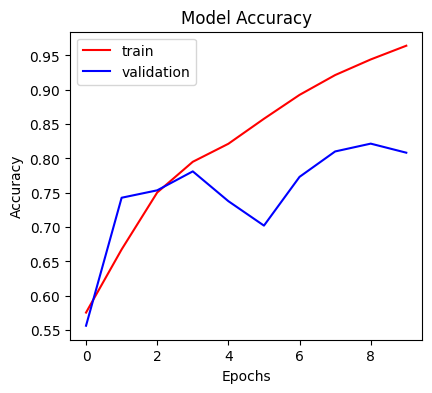

In [49]:
# ==========================================
# 6. EVALUATION (LOSS & ACCURACY PLOTS)
# ==========================================
# Plot Accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

#The difference is that red line and blue line shows overfitting is there.

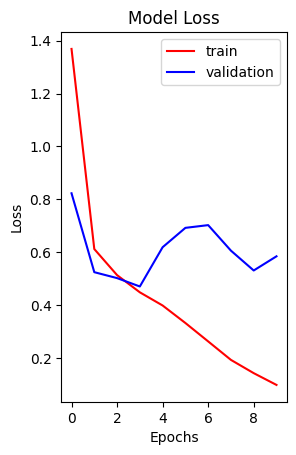

In [50]:
# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Implies the model is giving good results on training data but not on the test data

In [51]:
#Ways to reduce overfitting

# Add more data
# Data Augmentation
# L1/L2 Regularization
# Dropout
# Batch Normalization
# Reduce Complexity

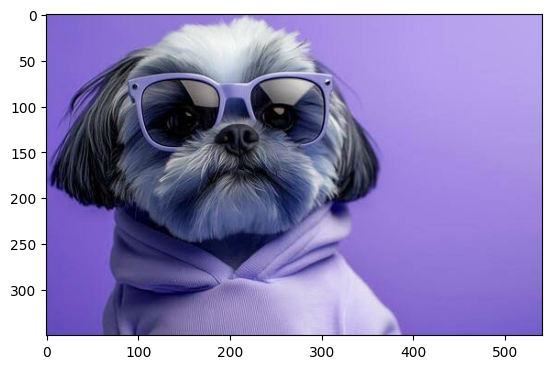

In [56]:
# ==========================================
# 7. INFERENCE (PREDICTING ON NEW IMAGES)
# ==========================================
# Replace path with your actual test image path (e.g., 'cat.jpg' or 'dog.jpg')

import cv2
image_path = '/content/dog1.jpg'
plt.imshow(cv2.imread(image_path))

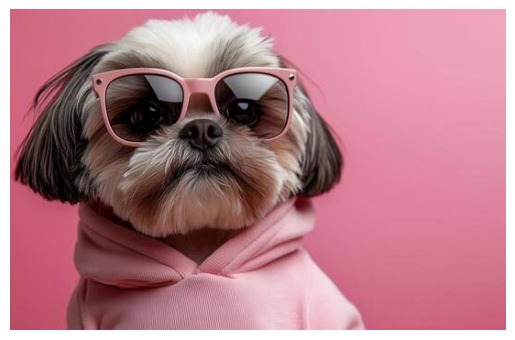

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Raw Prediction Value: 0.9723380208015442
Prediction: It's a DOG!


In [57]:

if os.path.exists(image_path):
    test_img = cv2.imread(image_path)
    # Convert BGR (OpenCV default) to RGB for correct matplotlib plotting
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.show()

    # Preprocess the image to fit model expectations
    test_img_resized = cv2.resize(test_img, (256, 256))
    test_input = test_img_resized.reshape((1, 256, 256, 3))

    # Scale image pixels if the training pipeline scales them
    test_input = test_input / 255.0

    # Prediction
    prediction = model.predict(test_input)
    print(f"Raw Prediction Value: {prediction[0][0]}")

    if prediction[0][0] < 0.5:
        print("Prediction: It's a CAT!")
    else:
        print("Prediction: It's a DOG!")
else:
    print(f"Image not found at {image_path}. Please check your path.")